In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [19]:
df = pd.read_csv(r'D:\\learning\\ScalerDSML\\assets\\Listings_dataset.csv')
df   

,Listing_Id,Posting_Date,Posting_Time,Location,Images,Bookings,Host_Type
0,4955430,13/05/2019,20:18:13,San Francisco,31,10,Regular
1,3338094,04-01-2016,05:30:37,Amsterdam,6,48,Regular
2,3132720,24/12/2018,12:26:15,Barcelona,25,10,Regular
3,3196344,14/10/2014,15:09:27,Berlin,10,134,Superhost
4,4588846,21/07/2016,09:26:48,Brussels,4,7,Regular
...,...,...,...,...,...,...,...
495,4103851,24/06/2017,20:30:56,San Jose,6,17,Regular
496,5590537,14/06/2016,18:46:44,London,16,89,Superhost
497,5074972,27/07/2017,08:36:09,Kyoto,15,145,Superhost
498,5230720,15/08/2015,20:58:58,Los Angeles,21,121,Regular


#### Q1. Bookings in 2015 <br/>
Using the below-given dataset, determine the average number of bookings in the year 2015.

In [88]:
df['Posting_Date_1'] = pd.to_datetime(df['Posting_Date'], format='%d-%m-%Y', errors='coerce')
df['Posting_Date_2'] = pd.to_datetime(df['Posting_Date'], format='%d/%m/%Y', errors='coerce')
df['Posting_Date'] = df['Posting_Date_1'].combine_first(df['Posting_Date_2'])
df['Year'] = df['Posting_Date'].dt.year

df.drop(columns=['Posting_Date_1', 'Posting_Date_2'], inplace=True)

df_2015 = df[df['Year'] == 2015][['Bookings','Year']]
print(f"Mean Bookings in 2015: {df_2015['Bookings'].mean()},   direct calculation: {df[df['Year'] == 2015]['Bookings'].mean()}")

df_2015.describe()

Mean Bookings in 2015: 87.91666666666667,   direct calculation: 87.91666666666667


,Bookings,Year
count,84.000000,84.0
mean,87.916667,2015.0
std,72.200559,0.0
min,0.000000,2015.0
25%,25.250000,2015.0
50%,80.000000,2015.0
75%,116.500000,2015.0
max,312.000000,2015.0


#### Q2. Top 10 bookings
Determine which of the following Indian cities is among the top 10 in terms of bookings.

In [41]:
df['Location'].value_counts().head(10)

Location
Madrid         27
Los Angeles    24
Mexico City    23
Berlin         21
Brussels       21
Bengaluru      21
Kyoto          21
Tunis          20
New Delhi      19
Vancouver      18
Name: count, dtype: int64

#### Q3. Number of bookings on average
Determine which host type has received a higher number of bookings on average.

In [53]:
print(f"value counts: {df['Host_Type'].value_counts()}")

df.groupby('Host_Type')['Bookings'].mean()

value counts: Host_Type
Regular      446
Superhost     54
Name: count, dtype: int64


Host_Type
Regular       32.829596
Superhost    150.814815
Name: Bookings, dtype: float64

#### Q4. Average redundant listings
Determine how many images for a listing resulted in higher average redundant listings.

In [89]:
df_redt = pd.DataFrame({
    'Property_Images':['0 to 2','3 to 5','6 to 10','11 to 15','15 to 20','21 to 25','26 to 30','> 30'],
    'Total_Listings':['563246','716923','1341164','993269','873269','635481','498456','384875'],
    'Redundant_Listings':['428368','264321','98874','53292','61382','29285','42473','28274']
})
df_redt['red_ratio'] = df_redt['Redundant_Listings'].astype(int) / df_redt['Total_Listings'].astype(int)
df_redt.sort_values('red_ratio', ascending=False, inplace=True)
df_redt

,Property_Images,Total_Listings,Redundant_Listings,red_ratio
0,0 to 2,563246,428368,0.760534
1,3 to 5,716923,264321,0.368688
6,26 to 30,498456,42473,0.085209
2,6 to 10,1341164,98874,0.073723
7,> 30,384875,28274,0.073463
4,15 to 20,873269,61382,0.070290
3,11 to 15,993269,53292,0.053653
5,21 to 25,635481,29285,0.046083


#### Q5. Number of active listings
Determine the number of images for a listing that had a higher number of total listings.

In [63]:
df_redt['Active_Listings'] = df_redt['Total_Listings'].astype(int) - df_redt['Redundant_Listings'].astype(int)
df_redt.sort_values('Active_Listings', ascending=False, inplace=True)
df_redt

,Property_Images,Total_Listings,Redundant_Listings,red_ratio,Active_Listings,active_ratio
2,6 to 10,1341164,98874,0.073723,1242290,0.926277
3,11 to 15,993269,53292,0.053653,939977,0.946347
4,15 to 20,873269,61382,0.070290,811887,0.929710
5,21 to 25,635481,29285,0.046083,606196,0.953917
6,26 to 30,498456,42473,0.085209,455983,0.914791
1,3 to 5,716923,264321,0.368688,452602,0.631312
7,> 30,384875,28274,0.073463,356601,0.926537
0,0 to 2,563246,428368,0.760534,134878,0.239466


#### Q6. What is the booking trend?
Determine the trend for the average number of bookings over the years

<Axes: xlabel='Year', ylabel='Bookings'>

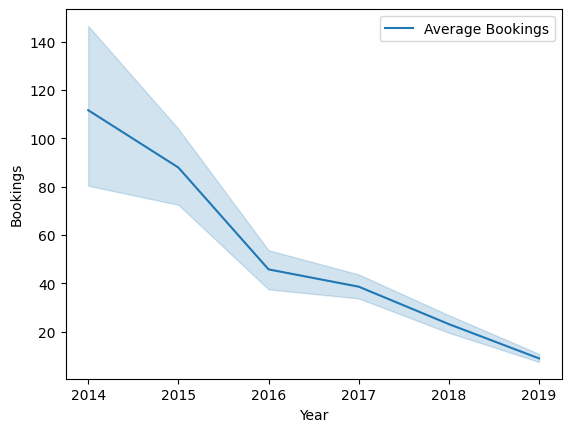

In [81]:
df_bookings = df.groupby('Year',as_index=False)['Bookings'].mean()
# df_bookings.plot.bar(x='Year')
sns.lineplot(data=df,x=df.Year,y='Bookings',estimator='mean',legend=True,label='Average Bookings')

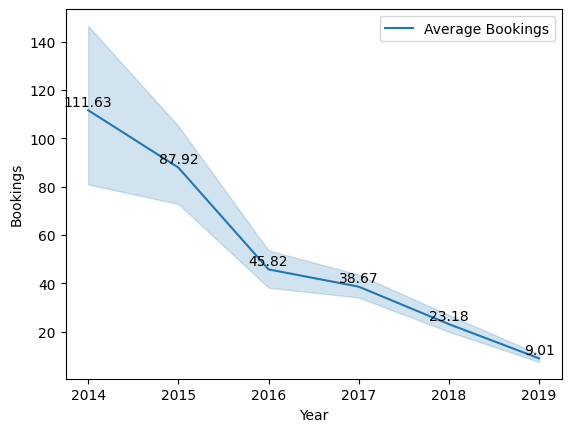

In [76]:
# 1. Your existing plot code
ax = sns.lineplot(data=df, x='Year', y='Bookings', estimator='mean', label='Average Bookings')

# 2. Add the numbers using your grouped dataframe
for i in range(len(df_bookings)):
    ax.text(df_bookings.Year[i],           # x position
            df_bookings.Bookings[i] + 0.5, # y position + small offset
            f'{df_bookings.Bookings[i]:.2f}', # formatted to 2 decimal places
            ha='center',                   # center horizontally
            va='bottom',                   # align to bottom of text
            fontsize=10)